# 2019 Hungarian Grand Prix Strategy Post-Mortem: The Overcut That Wasn't

## Racing Question:
Lewis Hamilton beat Max Verstappen in Hungary 2019(Hungoraring) without a single on-track overtake. How did pure strategy decide this race, and what does it reveal about stretching a tire stint too far?


## What Happened:
- Verstappen led comfortably for most of the race, running a long 42-lap second stint (laps 25-66) which was a clear bet on holding track position rather than pitting for fresh tires.
- The Mercedes strategy team took a more conventional approach: 2-stops (laps 30 & 47), which gave Hamilton a fresher final stint of 22 laps.
- By lap 65/70, the cumulative gap between Hamilton & Verstappen(built from each driver's session time) had shrunk from Verstappen's early ~2s lead to essentially zero; clear evidence that Hamilton's fresher tires were faster over the race distance, even without a single wheel-to-wheel overtaking move.
- When Verstappen was finally forced to pit at lap 66, he had no time cusion left to absorb the pit stop cost. The gap swung immediately in Hamilton's favor (+25s within two laps) and never recovered.

## Why It Matters:
This wasn't decided by pace on a single lap; it was decided by how long a tire stint can be stretched before degradation costs more than a pit stop saves. Verstappen/Red Bull's choice to hold out, let Hamilton close what should have been an unassailable gap purely through tire management.

## A Note on Method:
Raw lap times alone were a noisier signal than expected. Fuel burn-off and track evolution partially masked the degradation trend in each driver's individual pace. Comparing the *gap between* the two drivers(same track, same conditions, and same moment) was a cleaner way to isolate the tire effect than looking at either driver's raw lap times alone.

## Strategist Takeaway:
A long stint isn't free just because lap times don't obviously spike. The cost shows up in relative pace against a rival on fresher rubber, and by the time it is visible in the gap, it may already be too late to recover track position cheaply. 


In [2]:
import sys
print(sys.executable)

c:\condaenvs\f1-strategy\python.exe


In [1]:
import fastf1
import pandas as pd

# FastF1 caches downloaded data locally so you don't re-download every run
fastf1.Cache.enable_cache('../data/cache')

session = fastf1.get_session(2019, 'Hungary', 'R')
session.load()

print(session.event['EventName'])
laps = session.laps
print(laps[['Driver', 'LapNumber', 'LapTime', 'Compound']].head())

core           INFO 	Loading data for Hungarian Grand Prix - Race [v3.8.3]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
core        WARNING 	Driver 44 completed the race distance 00:00.069000 before the recorded end of the session.
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['44', '33', '5', '16', '55', '10', '7', '77', '4', '23', '11', '

Hungarian Grand Prix
  Driver  LapNumber                LapTime Compound
0    HAM        1.0 0 days 00:01:27.403000   MEDIUM
1    HAM        2.0 0 days 00:01:22.335000   MEDIUM
2    HAM        3.0 0 days 00:01:21.946000   MEDIUM
3    HAM        4.0 0 days 00:01:21.646000   MEDIUM
4    HAM        5.0 0 days 00:01:21.767000   MEDIUM


In [2]:
# Get all laps for the 2019 Hungarian Grand Prix
laps = session.laps

In [3]:
#Filtering out to just laps of Hamilton(HAM) & Verstappen(VER)
ham_laps = laps.pick_drivers('HAM')
ver_laps = laps.pick_drivers('VER')

print("Hamilton Laps:", len(ham_laps))
print("Verstappen Laps:", len(ver_laps))

Hamilton Laps: 70
Verstappen Laps: 70


In [4]:
#Get the key columns we care about for strategy analysis
cols = ['Driver', 'LapNumber', 'LapTime', 'Compound', 'Stint', 'PitInTime', 'PitOutTime']
pd.set_option('display.max_rows', None)
print(ham_laps[cols])

   Driver  LapNumber                LapTime Compound  Stint  \
0     HAM        1.0 0 days 00:01:27.403000   MEDIUM    1.0   
1     HAM        2.0 0 days 00:01:22.335000   MEDIUM    1.0   
2     HAM        3.0 0 days 00:01:21.946000   MEDIUM    1.0   
3     HAM        4.0 0 days 00:01:21.646000   MEDIUM    1.0   
4     HAM        5.0 0 days 00:01:21.767000   MEDIUM    1.0   
5     HAM        6.0 0 days 00:01:21.602000   MEDIUM    1.0   
6     HAM        7.0 0 days 00:01:21.658000   MEDIUM    1.0   
7     HAM        8.0 0 days 00:01:21.293000   MEDIUM    1.0   
8     HAM        9.0 0 days 00:01:21.535000   MEDIUM    1.0   
9     HAM       10.0 0 days 00:01:21.484000   MEDIUM    1.0   
10    HAM       11.0 0 days 00:01:21.574000   MEDIUM    1.0   
11    HAM       12.0 0 days 00:01:21.717000   MEDIUM    1.0   
12    HAM       13.0 0 days 00:01:21.651000   MEDIUM    1.0   
13    HAM       14.0 0 days 00:01:21.899000   MEDIUM    1.0   
14    HAM       15.0 0 days 00:01:21.696000   MEDIUM   

In [11]:
#Get the key columns we care about for strategy analysis
cols = ['Driver', 'LapNumber', 'LapTime', 'Compound', 'Stint', 'PitInTime', 'PitOutTime']
pd.set_option('display.max_rows', None)
print(ver_laps[cols])

    Driver  LapNumber                LapTime Compound  Stint  \
70     VER        1.0 0 days 00:01:25.604000   MEDIUM    1.0   
71     VER        2.0 0 days 00:01:21.854000   MEDIUM    1.0   
72     VER        3.0 0 days 00:01:21.863000   MEDIUM    1.0   
73     VER        4.0 0 days 00:01:21.763000   MEDIUM    1.0   
74     VER        5.0 0 days 00:01:21.542000   MEDIUM    1.0   
75     VER        6.0 0 days 00:01:21.686000   MEDIUM    1.0   
76     VER        7.0 0 days 00:01:21.611000   MEDIUM    1.0   
77     VER        8.0 0 days 00:01:21.391000   MEDIUM    1.0   
78     VER        9.0 0 days 00:01:21.545000   MEDIUM    1.0   
79     VER       10.0 0 days 00:01:21.571000   MEDIUM    1.0   
80     VER       11.0 0 days 00:01:21.763000   MEDIUM    1.0   
81     VER       12.0 0 days 00:01:21.555000   MEDIUM    1.0   
82     VER       13.0 0 days 00:01:21.638000   MEDIUM    1.0   
83     VER       14.0 0 days 00:01:21.844000   MEDIUM    1.0   
84     VER       15.0 0 days 00:01:21.63

In [5]:
#show only the laps where a pit stop was made
pit_laps = ham_laps[ham_laps['PitInTime'].notna()]
print(pit_laps[cols])

   Driver  LapNumber                LapTime Compound  Stint  \
30    HAM       31.0 0 days 00:01:25.483000   MEDIUM    1.0   
47    HAM       48.0 0 days 00:01:22.452000     HARD    2.0   

                PitInTime PitOutTime  
30 0 days 01:15:16.009000        NaT  
47 0 days 01:38:26.659000        NaT  


In [8]:
# Shows where only VER made a pit stop
ver_pit_laps = ver_laps[ver_laps['PitInTime'].notna()]
print(ver_pit_laps[cols])

    Driver  LapNumber                LapTime Compound  Stint  \
94     VER       25.0 0 days 00:01:24.195000   MEDIUM    1.0   
136    VER       67.0 0 days 00:01:25.724000     HARD    2.0   

                 PitInTime PitOutTime  
94  0 days 01:07:00.320000        NaT  
136 0 days 02:03:53.303000        NaT  


In [9]:
#calculating gap between HAM & VER lap by lap
merged = pd.merge(
    ham_laps[['LapNumber', 'Time']], 
    ver_laps[['LapNumber', 'Time']], 
    on='LapNumber', 
    suffixes=('_HAM', '_VER')
)

# 'Time' in FastF1 is cumulative elapsed session time at the end of each lap
# So subtracting gives us the gap between them at that point in the race

merged['Gap_VER_minus_HAM'] = (merged['Time_VER'] - merged['Time_HAM']).dt.total_seconds()

In [10]:
print(merged[['LapNumber', 'Gap_VER_minus_HAM']])

    LapNumber  Gap_VER_minus_HAM
0         1.0             -1.799
1         2.0             -2.280
2         3.0             -2.363
3         4.0             -2.246
4         5.0             -2.471
5         6.0             -2.387
6         7.0             -2.434
7         8.0             -2.336
8         9.0             -2.326
9        10.0             -2.239
10       11.0             -2.050
11       12.0             -2.212
12       13.0             -2.225
13       14.0             -2.280
14       15.0             -2.344
15       16.0             -2.113
16       17.0             -1.852
17       18.0             -1.783
18       19.0             -1.440
19       20.0             -1.464
20       21.0             -1.343
21       22.0             -1.409
22       23.0             -1.057
23       24.0             -1.279
24       25.0              0.864
25       26.0             18.874
26       27.0             17.997
27       28.0             17.537
28       29.0             17.246
29       3

In [12]:
#Plot the data
import matplotlib.pyplot as plt

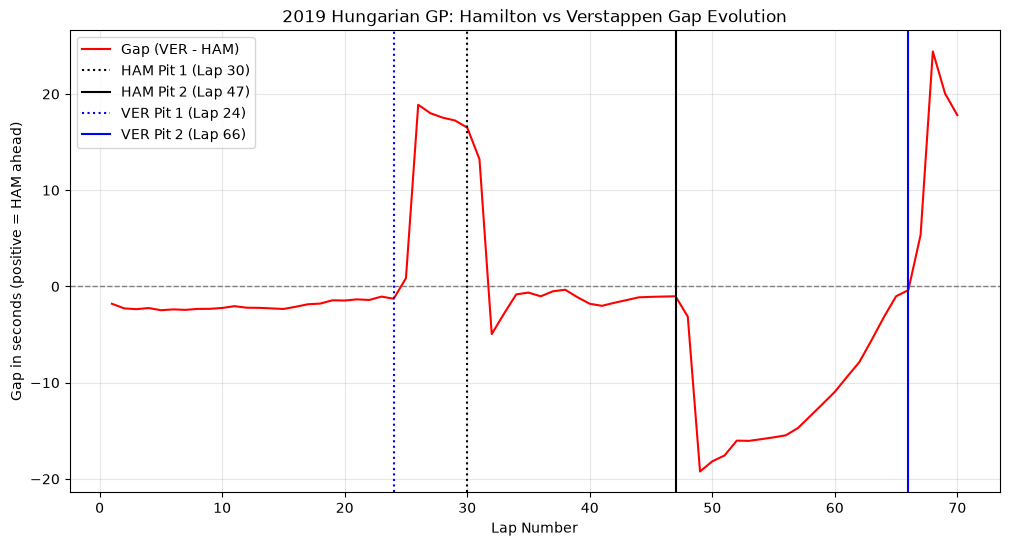

In [18]:
plt.figure(figsize=(12, 6))
plt.plot(merged['LapNumber'], merged['Gap_VER_minus_HAM'], label='Gap (VER - HAM)', color='red')

# Zero line for reference — above zero means Hamilton ahead, below means Verstappen ahead
plt.axhline(0, color='gray', linestyle='--', linewidth=1)

# Mark pit stops — using the lap numbers we found earlier
plt.axvline(30, color='black', linestyle=':', label='HAM Pit 1 (Lap 30)')
plt.axvline(47, color='black', linestyle='-', label='HAM Pit 2 (Lap 47)')
plt.axvline(24, color='blue', linestyle=':', label='VER Pit 1 (Lap 24)')
plt.axvline(66, color='blue', linestyle='-', label='VER Pit 2 (Lap 66)')

plt.xlabel('Lap Number')
plt.ylabel('Gap in seconds (positive = HAM ahead)')
plt.title('2019 Hungarian GP: Hamilton vs Verstappen Gap Evolution')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

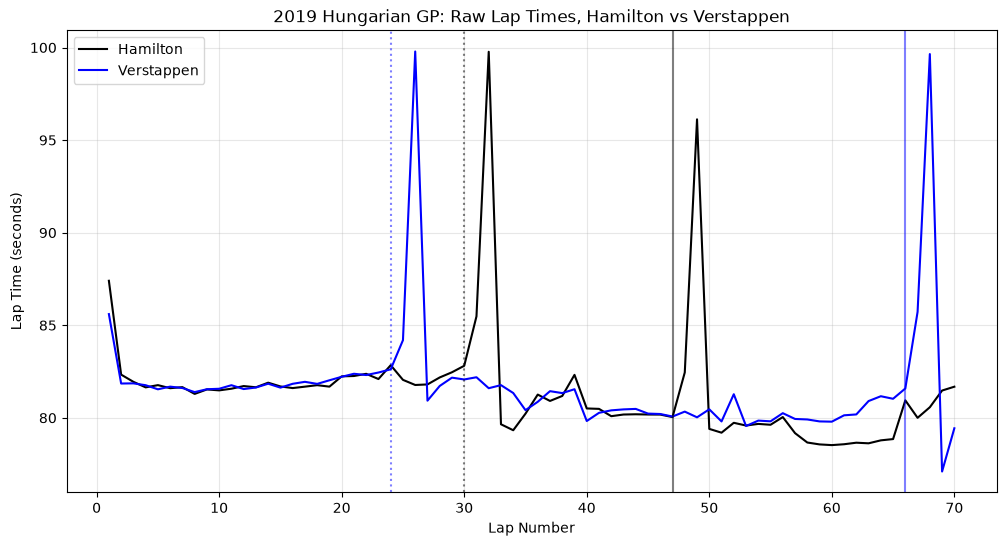

In [ ]:
#Plotting tire degradation and lap times for both drivers
plt.figure(figsize=(12, 6))

# Convert LapTime (a timedelta) into plain seconds for plotting
ham_laptimes = ham_laps['LapTime'].dt.total_seconds()
ver_laptimes = ver_laps['LapTime'].dt.total_seconds()

plt.plot(ham_laps['LapNumber'], ham_laptimes, label='Hamilton', color='black')
plt.plot(ver_laps['LapNumber'], ver_laptimes, label='Verstappen', color='blue')

# Same pit markers as before, so we can see stints line up with pace
plt.axvline(30, color='black', linestyle=':', alpha=0.5)
plt.axvline(47, color='black', linestyle='-', alpha=0.5)
plt.axvline(24, color='blue', linestyle=':', alpha=0.5)
plt.axvline(66, color='blue', linestyle='-', alpha=0.5)

plt.xlabel('Lap Number')
plt.ylabel('Lap Time (seconds)')
plt.title('2019 Hungarian GP: Raw Lap Times, Hamilton vs Verstappen')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

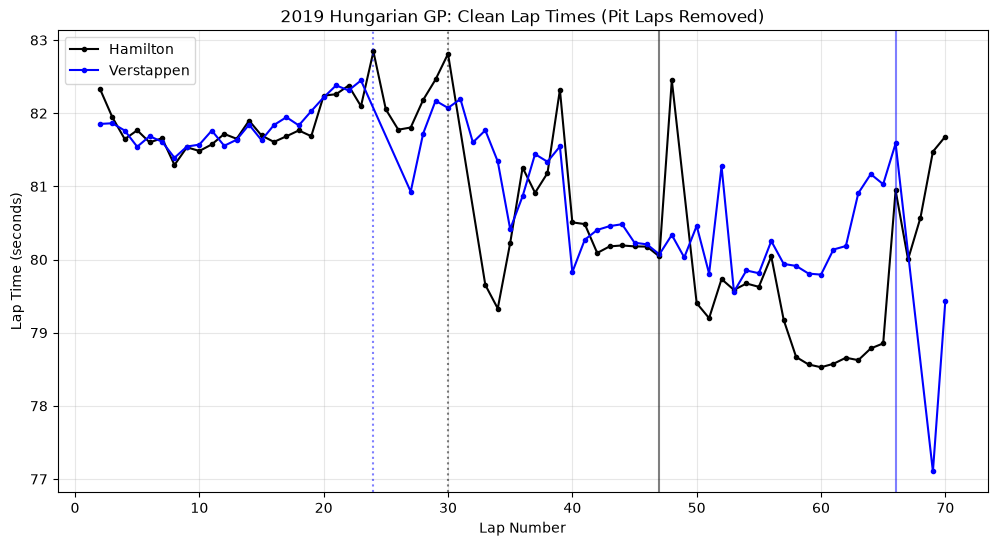

In [20]:
#Plot of filtered laps to isolate the real tire degradation trend(no pit in/out laps)
plt.figure(figsize=(12, 6))

# pick_quicklaps() removes pit in/out laps and outlier slow laps automatically
ham_clean = ham_laps.pick_quicklaps()
ver_clean = ver_laps.pick_quicklaps()

plt.plot(ham_clean['LapNumber'], ham_clean['LapTime'].dt.total_seconds(), label='Hamilton', color='black', marker='o', markersize=3)
plt.plot(ver_clean['LapNumber'], ver_clean['LapTime'].dt.total_seconds(), label='Verstappen', color='blue', marker='o', markersize=3)

plt.axvline(30, color='black', linestyle=':', alpha=0.5)
plt.axvline(47, color='black', linestyle='-', alpha=0.5)
plt.axvline(24, color='blue', linestyle=':', alpha=0.5)
plt.axvline(66, color='blue', linestyle='-', alpha=0.5)

plt.xlabel('Lap Number')
plt.ylabel('Lap Time (seconds)')
plt.title('2019 Hungarian GP: Clean Lap Times (Pit Laps Removed)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()